In [7]:
# Import required libraries
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
import torch

In [ ]:
# Different Model Configurations

model_name = "MLRS/BERTu"
output_dir = "./multi_model_runs"
os.makedirs(output_dir, exist_ok = True)

model_runs = [
        {
        "run_name": "BERTu_lr2e5_bs16_wd001",
        "learning_rate": 1e-4,
        "per_device_train_batch_size": 32,
        "per_device_eval_batch_size": 32,
        "num_train_epochs": 200,
        "weight_decay": 0.01,
        "max_length": 128,
    },
    {
        "run_name": "1_lr2e5_bs16_wd001",
        "learning_rate": 2e-5,
        "per_device_train_batch_size": 16,
        "per_device_eval_batch_size": 16,
        "num_train_epochs": 200,
        "weight_decay": 0.01,
        "max_length": 128,
    },
    {
        "run_name": "2_lr3e5_bs16_wd001",
        "learning_rate": 3e-5,
        "per_device_train_batch_size": 16,
        "per_device_eval_batch_size": 16,
        "num_train_epochs": 200,
        "weight_decay": 0.01,
        "max_length": 128,
    },    
    {
        "run_name": "3_lr3e5_bs16_wd001",
        "learning_rate": 1e-5,
        "per_device_train_batch_size": 16,
        "per_device_eval_batch_size": 16,
        "num_train_epochs": 200,
        "weight_decay": 0.01,
        "max_length": 128,
    },     
    {
        "run_name": "4_lr2e5_bs16_wd005",
        "learning_rate": 2e-5,
        "per_device_train_batch_size": 16,
        "per_device_eval_batch_size": 16,
        "num_train_epochs": 200,
        "weight_decay": 0.05,
        "max_length": 128,
    },
    {
        "run_name": "5_lr2e5_bs16_wd01",
        "learning_rate": 2e-5,
        "per_device_train_batch_size": 16,
        "per_device_eval_batch_size": 16,
        "num_train_epochs": 200,
        "weight_decay": 0.1,
        "max_length": 128,
    },
    {
        "run_name": "6_lr2e5_bs32_wd001",
        "learning_rate": 2e-5,
        "per_device_train_batch_size": 32,
        "per_device_eval_batch_size": 32,
        "num_train_epochs": 200,
        "weight_decay": 0.01,
        "max_length": 128,
    },
    {
        "run_name": "7_lr3e5_bs32_wd001",
        "learning_rate": 3e-5,
        "per_device_train_batch_size": 32,
        "per_device_eval_batch_size": 32,
        "num_train_epochs": 200,
        "weight_decay": 0.01,
        "max_length": 128,
    },
    {
        "run_name": "8_lr2e5_bs32_wd005",
        "learning_rate": 2e-5,
        "per_device_train_batch_size": 32,
        "per_device_eval_batch_size": 32,
        "num_train_epochs": 200,
        "weight_decay": 0.05,
        "max_length": 128,
    },
    {
        "run_name": "9_lr3e5_bs32_wd005",
        "learning_rate": 3e-5,
        "per_device_train_batch_size": 32,
        "per_device_eval_batch_size": 32,
        "num_train_epochs": 200,
        "weight_decay": 0.05,
        "max_length": 128,
    },
        {
        "run_name": "10_lr3e5_bs32_wd01",
        "learning_rate": 3e-5,
        "per_device_train_batch_size": 32,
        "per_device_eval_batch_size": 32,
        "num_train_epochs": 200,
        "weight_decay": 0.1,
        "max_length": 128,
    },
]

# Mapping the dataset results
label_map = {
    0: "Harmful Content",
    1: "Non-Harmful Content",
}

In [9]:
# Load the Maltese Semantic Analysis Dataset
dataset = load_dataset("DGurgurov/maltese_sa")

# Load different datasets into Data Frame variables
train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

print("Train label counts:")
print(train_df["label"].value_counts())

print("\nValidation label counts:")
print(val_df["label"].value_counts())

print("\nTest label counts:")
print(test_df["label"].value_counts())

Train label counts:
label
0    413
1    182
Name: count, dtype: int64

Validation label counts:
label
0    56
1    29
Name: count, dtype: int64

Test label counts:
label
0    111
1     60
Name: count, dtype: int64


In [10]:
# Metrics Function
def compute_metrics(eval_pred):

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis = -1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }

In [11]:
def get_run_dirs(run_name):
    run_dir = os.path.join(output_dir, run_name)
    return {
        "run_dir": run_dir,
        "results_dir": os.path.join(run_dir, "results"),
        "logs_dir": os.path.join(run_dir, "logs"),
        "saved_model_dir": os.path.join(run_dir, "saved_model"),
        "plots_dir": os.path.join(run_dir, "plots"),
        "predictions_dir": os.path.join(run_dir, "predictions"),
    }

In [12]:
# Train the models
all_results = []

for run in model_runs:
    run_name = run["run_name"]
    max_length = run["max_length"]

    print("\n" + "=" * 80)
    print(f"Starting run: {run_name}")
    print("=" * 80)

    dirs = get_run_dirs(run_name)
    for path in dirs.values():
        os.makedirs(path, exist_ok = True)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels = 2
    )

    def tokenize_function(batch):
        return tokenizer(batch["text"], truncation = True, max_length = max_length)

    tokenized_dataset = dataset.map(tokenize_function, batched = True)
    data_collator = DataCollatorWithPadding(tokenizer = tokenizer)

    training_args = TrainingArguments(
        output_dir = dirs["results_dir"],
        eval_strategy = "epoch",
        save_strategy = "epoch",
        learning_rate = run["learning_rate"],
        per_device_train_batch_size = run["per_device_train_batch_size"],
        per_device_eval_batch_size = run["per_device_eval_batch_size"],
        num_train_epochs = run["num_train_epochs"],
        weight_decay = run["weight_decay"],
        logging_dir = dirs["logs_dir"],
        load_best_model_at_end = True,
        metric_for_best_model = "macro_f1",
        greater_is_better = True,
        disable_tqdm = True,
        save_total_limit = 2,
        report_to = "none",
        #warmup_ratio=0.1,
        #lr_scheduler_type="linear",
    )

    trainer = Trainer(
        model = model,
        args = training_args,
        train_dataset = tokenized_dataset["train"],
        eval_dataset = tokenized_dataset["validation"],
        data_collator = data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=20)],
    )

    trainer.train()

    val_results = trainer.evaluate(tokenized_dataset["validation"])
    test_results = trainer.evaluate(tokenized_dataset["test"])

    print("Validation results:", val_results)
    print("Test results:", test_results)

    # Save best model + tokenizer
    trainer.save_model(dirs["saved_model_dir"])
    tokenizer.save_pretrained(dirs["saved_model_dir"])
    print(f"Saved model and tokenizer to: {dirs['saved_model_dir']}")

    # Save raw predictions for plotting in later cells
    predictions = trainer.predict(tokenized_dataset["test"])
    y_true = predictions.label_ids
    y_pred = np.argmax(predictions.predictions, axis=1)

    np.save(os.path.join(dirs["predictions_dir"], "y_true.npy"), y_true)
    np.save(os.path.join(dirs["predictions_dir"], "y_pred.npy"), y_pred)

    # Save run summary
    run_summary = {
        "run_name": run_name,
        "learning_rate": run["learning_rate"],
        "train_batch_size": run["per_device_train_batch_size"],
        "eval_batch_size": run["per_device_eval_batch_size"],
        "num_train_epochs": run["num_train_epochs"],
        "weight_decay": run["weight_decay"],
        "max_length": run["max_length"],
        "val_accuracy": val_results.get("eval_accuracy"),
        "val_precision": val_results.get("eval_precision"),
        "val_recall": val_results.get("eval_recall"),
        "val_f1": val_results.get("eval_f1"),
        "test_accuracy": test_results.get("eval_accuracy"),
        "test_precision": test_results.get("eval_precision"),
        "test_recall": test_results.get("eval_recall"),
        "test_f1": test_results.get("eval_f1"),
        "model_path": dirs["saved_model_dir"],
        "plots_path": dirs["plots_dir"],
        "results_dir": dirs["results_dir"],
    }

    with open(os.path.join(dirs["run_dir"], "run_summary.json"), "w", encoding="utf-8") as f:
        json.dump(run_summary, f, indent=4)

    all_results.append(run_summary)

results_df = pd.DataFrame(all_results).sort_values(by="val_f1", ascending=False)
results_df.to_csv(os.path.join(output_dir, "all_model_results.csv"), index=False)

print("\nFinal comparison table:")
print(results_df)


Starting run: model_BERTu


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: MLRS/BERTu
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your do

{'eval_loss': '0.3014', 'eval_accuracy': '0.8471', 'eval_macro_precision': '0.8525', 'eval_macro_recall': '0.8008', 'eval_macro_f1': '0.8179', 'eval_runtime': '0.278', 'eval_samples_per_second': '305.8', 'eval_steps_per_second': '10.79', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

{'eval_loss': '0.5327', 'eval_accuracy': '0.9176', 'eval_macro_precision': '0.9061', 'eval_macro_recall': '0.9126', 'eval_macro_f1': '0.9091', 'eval_runtime': '0.209', 'eval_samples_per_second': '406.7', 'eval_steps_per_second': '28.71', 'epoch': '26'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.0001268', 'grad_norm': '0.001143', 'learning_rate': '1.474e-05', 'epoch': '26.32'}
{'eval_loss': '0.5338', 'eval_accuracy': '0.9176', 'eval_macro_precision': '0.9061', 'eval_macro_recall': '0.9126', 'eval_macro_f1': '0.9091', 'eval_runtime': '0.209', 'eval_samples_per_second': '406.7', 'eval_steps_per_second': '28.71', 'epoch': '27'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(all_results).sort_values(by="val_f1", ascending=False)
results_df.to_csv(os.path.join(output_dir, "all_model_results.csv"), index=False)

print("\nFinal comparison table:")
print(results_df)


Final comparison table:
                   run_name  learning_rate  train_batch_size  eval_batch_size  \
4  model_5_lr2e5_bs32_wd001        0.00002                32               32   
1  model_2_lr3e5_bs16_wd001        0.00003                16               16   
7  model_8_lr3e5_bs32_wd005        0.00003                32               32   
6  model_7_lr2e5_bs32_wd005        0.00002                32               32   
5  model_6_lr3e5_bs32_wd001        0.00003                32               32   
3  model_4_lr2e5_bs16_wd005        0.00002                16               16   
2  model_3_lr3e5_bs16_wd001        0.00001                16               16   
0  model_1_lr2e5_bs16_wd001        0.00002                16               16   

   num_train_epochs  weight_decay  max_length  val_accuracy  val_precision  \
4               100          0.01         128      0.929412       0.870968   
1               100          0.01         128      0.917647       0.843750   
7          

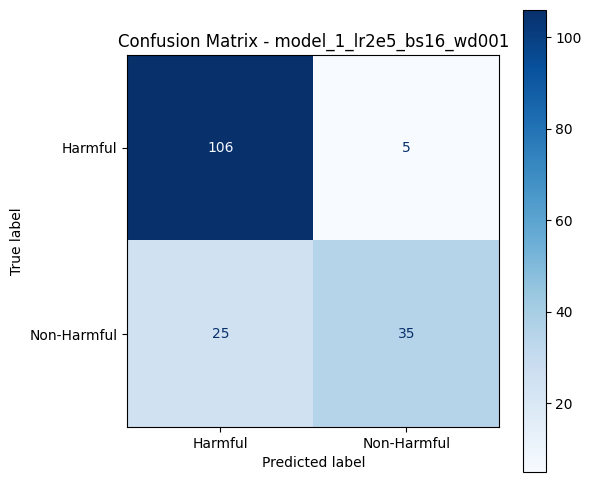

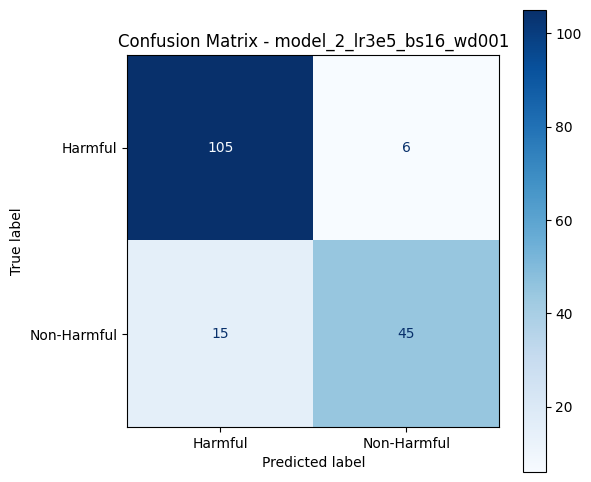

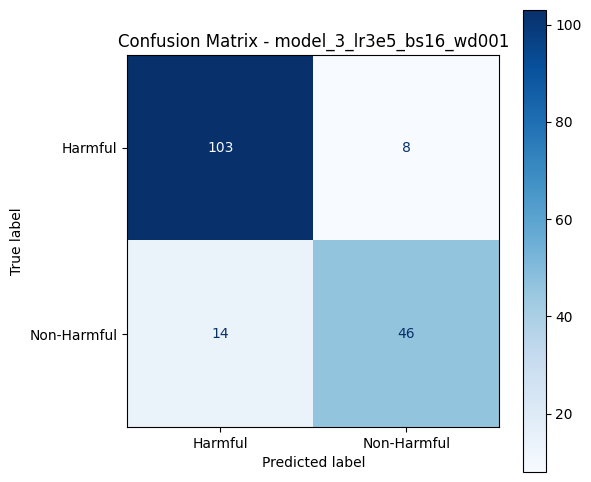

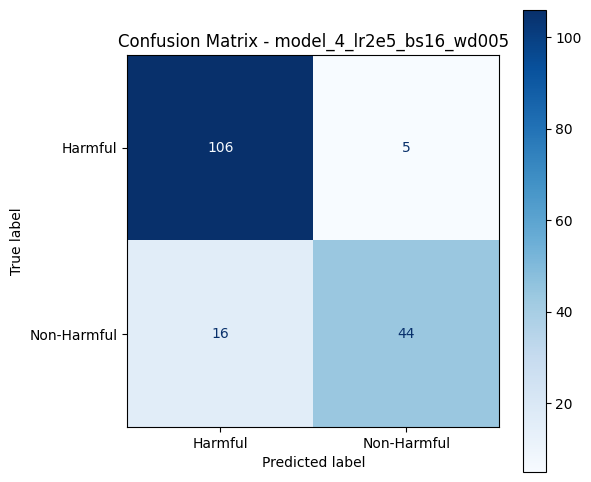

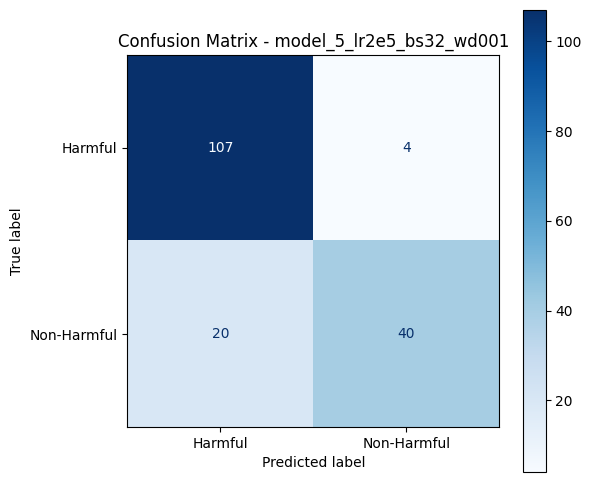

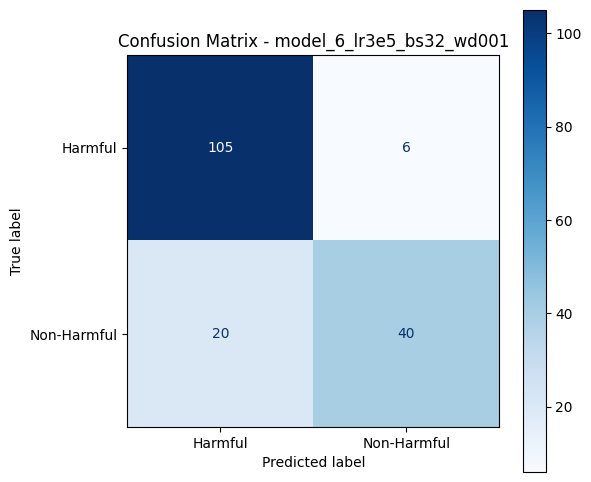

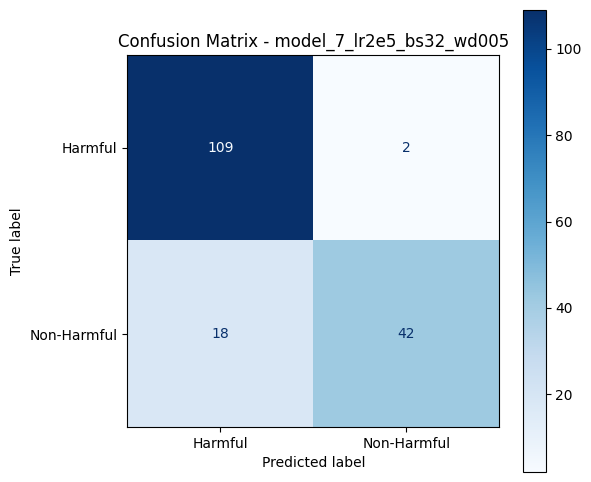

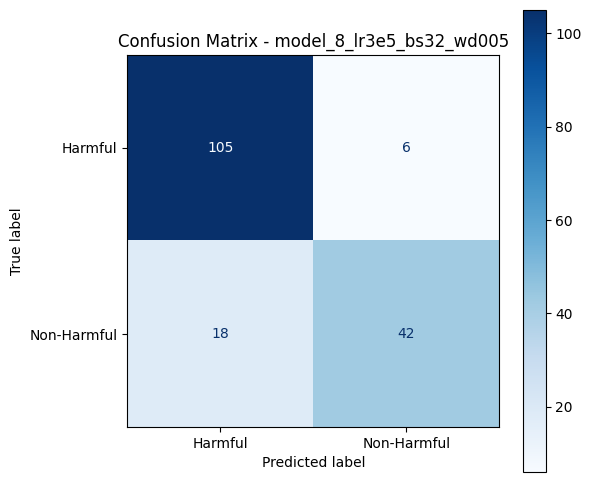

In [ ]:
# Confusion Matrix Plot
for run in model_runs:
    run_name = run["run_name"]
    dirs = get_run_dirs(run_name)

    y_true_path = os.path.join(dirs["predictions_dir"], "y_true.npy")
    y_pred_path = os.path.join(dirs["predictions_dir"], "y_pred.npy")

    if not (os.path.exists(y_true_path) and os.path.exists(y_pred_path)):
        print(f"Skipping {run_name}: prediction files not found.")
        continue

    y_true = np.load(y_true_path)
    y_pred = np.load(y_pred_path)

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Harmful", "Non-Harmful"]
    )
    disp.plot(cmap="Blues", values_format="d", ax=ax)
    ax.set_title(f"Confusion Matrix - {run_name}")

    cm_path = os.path.join(dirs["plots_dir"], f"{run_name}_confusion_matrix.png")
    fig.savefig(cm_path, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)

In [ ]:
# Training Curves Plot
for run in model_runs:
    run_name = run["run_name"]
    dirs = get_run_dirs(run_name)

    # Find trainer_state.json inside checkpoint folders
    state_files = glob.glob(os.path.join(dirs["results_dir"], "checkpoint-*", "trainer_state.json"))

    if not state_files:
        print(f"Skipping {run_name}: no trainer_state.json found inside checkpoint folders.")
        continue

    # Sort checkpoints by checkpoint number
    state_files = sorted(
        state_files,
        key=lambda x: int(os.path.basename(os.path.dirname(x)).split("-")[-1])
    )

    latest_state_file = state_files[-1]
    print(f"Using for {run_name}: {latest_state_file}")

    with open(latest_state_file, "r", encoding="utf-8") as f:
        trainer_state = json.load(f)

    logs = trainer_state.get("log_history", [])
    df_logs = pd.DataFrame(logs)

    required_cols = ["epoch", "eval_f1", "eval_precision", "eval_recall"]
    missing_cols = [col for col in required_cols if col not in df_logs.columns]

    if missing_cols:
        print(f"Skipping {run_name}: missing columns {missing_cols}")
        continue

    eval_df = df_logs.dropna(subset=required_cols).copy()

    if eval_df.empty:
        print(f"Skipping {run_name}: no evaluation rows found.")
        continue

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(eval_df["epoch"], eval_df["eval_f1"], marker="o", label="F1 Score")
    ax.plot(eval_df["epoch"], eval_df["eval_precision"], marker="o", label="Precision")
    ax.plot(eval_df["epoch"], eval_df["eval_recall"], marker="o", label="Recall")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_title(f"Model Performance During Training - {run_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    curves_path = os.path.join(dirs["plots_dir"], f"{run_name}_training_curves.png")
    fig.savefig(curves_path, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)

    print(f"Saved training curves to: {curves_path}")

Skipping model_1_lr2e5_bs16_ep10_wd001: trainer_state.json not found.
Skipping model_2_lr3e5_bs16_ep10_wd001: trainer_state.json not found.
Skipping model_3_lr2e5_bs32_ep10_wd001: trainer_state.json not found.
Skipping model_4_lr2e5_bs16_ep15_wd005: trainer_state.json not found.


In [ ]:
# Get best model from results

results_csv_path = os.path.join(base_output_dir, "all_model_results.csv")
results_df = pd.read_csv(results_csv_path).sort_values(by="val_f1", ascending=False)

best_run = results_df.iloc[0].to_dict()
best_run_path = os.path.join(base_output_dir, "best_model_summary.json")

with open(best_run_path, "w", encoding="utf-8") as f:
    json.dump(best_run, f, indent=4)

print("Best run:")
print(json.dumps(best_run, indent=4))
print(f"Saved best model summary to: {best_run_path}")

NameError: name 'base_output_dir' is not defined

In [ ]:
# Load saved model and prediction function
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def load_model_and_predict(model_path, text, max_length=128):
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )

    outputs = model(**inputs)
    prediction = int(outputs.logits.argmax(dim=-1).item())
    return label_map[prediction]

In [ ]:
# Run prediction on model

# Define path of model to load
model_path = "./multi_model_runs/model_1_lr2e5_bs16_ep10_wd001/saved_model"

# Define text to run sentiment analysis on
comments = [
    "Prosit tassew għal dan ix-xogħol.",
    "Int ma tifhem xejn, vera stupidu.",
    "Mur lura fejn ġejt.",
    "Ma naqbilx miegħek imma nirrispettak."
]

for text in comments:
    print(text, "-", load_model_and_predict(model_path, text))